# 堆

[返回总目录](README.md) · [打开进度表](LeetCode%20Hot100与高频题目刷题清单与进度追踪表.xlsx)

主分类采用 [LeetCode Hot100 官网](https://leetcode.cn/studyplan/top-100-liked/)。扩展题紧邻相关题；解法标签可与主分类不同。原笔记中的局部编号保留，以本目录中的 LeetCode 题号为准。

## 本文目录

- [215. 数组中的第K个最大元素](#lc-215) — Hot100；已有详细笔记
- [295. 数据流的中位数](#lc-295) — Hot100；已有详细笔记


## lc-215

**215. 数组中的第K个最大元素**

堆 / 第K大与快速选择 · Hot100 · 中等

[官网题目](https://leetcode.cn/problems/kth-largest-element-in-an-array/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：快速选择 / 堆。

表格摘要：快速选择partition（随机pivot）期望O(n)；或维护大小为k的小顶堆


**_#6.数组中的第k个最大元素_**
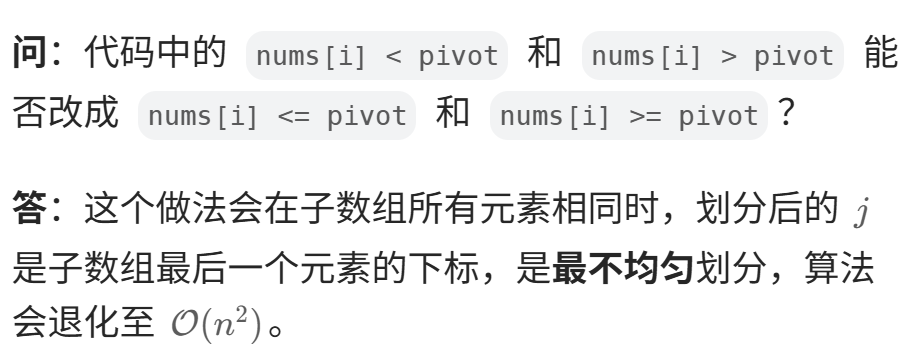

使用快速排序算法时要考虑含有大量重复元素对划分的影响，从而选择划分过程中是否有等号

In [ ]:
from random import random

class Solution:
    def partiton(self,nums,k:int,left:int,right:int) -> int:
        pivotIndex = random.randint(left,right)
        nums[left],nums[pivotIndex] = nums[pivotIndex],nums[left]
        pivot = nums[left]

        lt = left + 1
        gt = right

        while True:
            while lt <= gt and nums[lt] < pivot:#注意这里不能写小于等于，因为如果数组中的数都相等的话那么j最终返回的是数组的最后一个元素的下标，而写小于的话那么i与j最终都会出现在中间部分，以保证均匀的划分
                lt += 1
            while lt <= gt and nums[gt] > pivot:
                gt -= 1
            if lt > gt:
                break

            nums[lt],nums[gt] = nums[gt],nums[lt]#交换之后lt和gt都要进行变化
            lt += 1
            gt -= 1

        nums[left],nums[gt] = nums[gt],nums[left]
        return gt

    def findKthLargest(self, nums, k: int) -> int:#使用循环的方式来解决问题而非递归
        left,right = 0,len(nums)-1
        n = right - left + 1
        while True:
            i = self.partiton(nums,k,left,right)
            if i == n - k:
                return nums[i]
            if i < n - k:
                left = i + 1
            else:
                right = i - 1

## lc-295

**295. 数据流的中位数**

堆 / 对顶堆 · Hot100 · 困难

[官网题目](https://leetcode.cn/problems/find-median-from-data-stream/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：设计 / 双指针 / 数据流 / 排序 / 堆（优先队列）。

表格摘要：此题的思路时使用最大堆与最小堆存储数据，但因为python只有最小堆，因此采用存储相反数的形式来实现最大堆，取出时记得将数取反即可。 当左右堆大小相等的时候，不要直接向左堆中加入数据，应该先加入到右堆中，然后取出新的右堆…


**_#1.数据流的中位数_**

此题的思路时使用最大堆与最小堆存储数据，但因为python只有最小堆，因此采用存储相反数的形式来实现最大堆，取出时记得将数取反即可。
当左右堆大小相等的时候，不要直接向左堆中加入数据，应该先加入到右堆中，然后取出新的右堆的最小值加入到左堆中，因为向左堆中加入数据一共有两种情况，一是加入的数比较小，二是加入的数比较大，而这两种情况可以合并。同理，在左堆比右堆大一的情况下，应先将数据加入到左堆中，才取出左堆中的最大值加入到右堆以满足左堆元素小于右堆元素的性质。
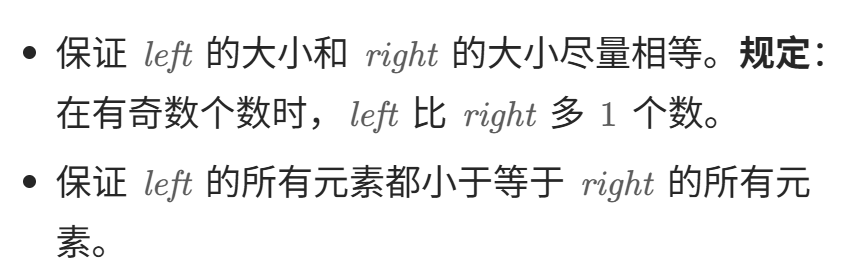

In [1]:
from heapq import heappush, heappushpop


class MedianFinder:

    def __init__(self):
        self.left = [] #最大堆
        self.right = [] #最小堆

    def addNum(self, num: int) -> None:
        if len(self.left) == len(self.right):
            heappush(self.left,-heappushpop(self.right,num))#右堆弹出的元素放在左堆中就是最大的，python只有最小堆，因此取负值后加入左堆就能保证值位于堆顶
        else:
            heappush(self.right,-heappushpop(self.left,-num))#左堆中存储的都是元素的相反数，这样才能实现最大堆的效果，弹出时要进行转换

    def findMedian(self) -> float:
        if len(self.left) == len(self.right):
            return (-self.left[0] + self.right[0]) / 2
        else:
            return -self.left[0]#往最大堆中加入，取出，获取值的时候都要取相反数


# Your MedianFinder object will be instantiated and called as such:
# obj = MedianFinder()
# obj.addNum(num)
# param_2 = obj.findMedian()